# Week 12 - Ensemble Learning: Boosting

Last week, we saw that **bagging** (**b**ootstrap **agg**regation) averages multiple classifiers or regressors fitted to different bootstrapped data samples, which has the effect of reducing the variance of the individual models and regularizing their fits to improve generalization (test performance).

This week, we continue our work with ensemble models, of which bagging is a special case. This week we cover **boosting**.

Boosting throws out bootstrapping in favor of sequential samples that push the individual models to focus on points where the model makes errors. This is primarily used to solve underfitting.

# Lecture 16 - Boosting and AdaBoost

First, let's import some things.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_wine
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import cifar10

2026-02-14 12:50:32.141747: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-14 12:50:32.166385: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-14 12:50:32.703958: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



Training Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       156
           1       1.00      1.00      1.00       270

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426


Testing Classification Report:

               precision    recall  f1-score   support

           0       0.96      0.98      0.97        56
           1       0.99      0.98      0.98        87

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143


Testing Confusion Matrix:



<Figure size 640x480 with 0 Axes>

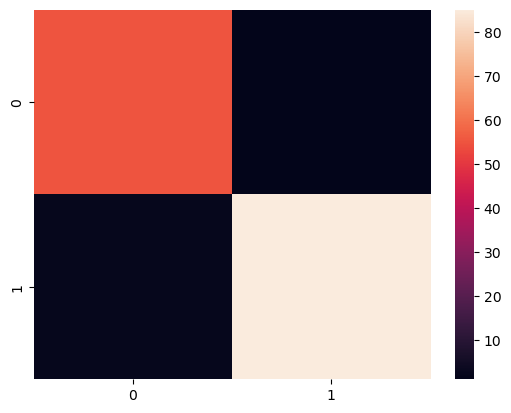

<Figure size 640x480 with 0 Axes>

In [2]:
data = load_breast_cancer()

X = data['data']
Y = data['target']

# split the data into train and test sets
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# build the classifier
model = AdaBoostClassifier()

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()


Training Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        49
           2       1.00      1.00      1.00        40

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133


Testing Classification Report:

               precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.91      0.95      0.93        22
           2       0.88      0.88      0.88         8

    accuracy                           0.93        45
   macro avg       0.93      0.92      0.92        45
weighted avg       0.94      0.93      0.93        45


Testing Confusion Matrix:



<Figure size 640x480 with 0 Axes>

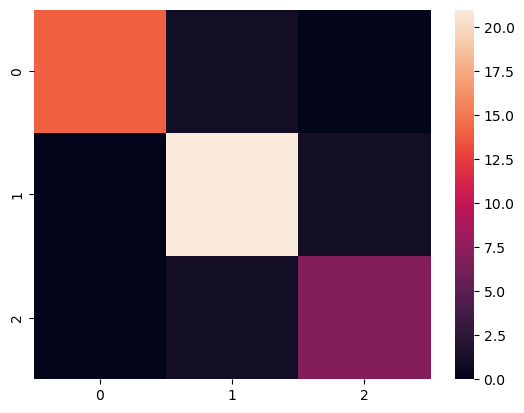

<Figure size 640x480 with 0 Axes>

In [3]:
data = load_wine()

X = data['data']
Y = data['target']

# split the data into train and test sets
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# build the classifier
model = AdaBoostClassifier()

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

Let's try the MNIST dataset with AdaBoost.


Training Classification Report:

               precision    recall  f1-score   support

           0       0.87      0.62      0.73      5923
           1       0.88      0.88      0.88      6742
           2       0.69      0.72      0.71      5958
           3       0.67      0.64      0.65      6131
           4       0.66      0.75      0.70      5842
           5       0.47      0.52      0.50      5421
           6       0.82      0.81      0.81      5918
           7       0.82      0.73      0.77      6265
           8       0.61      0.77      0.68      5851
           9       0.58      0.53      0.55      5949

    accuracy                           0.70     60000
   macro avg       0.71      0.70      0.70     60000
weighted avg       0.71      0.70      0.70     60000


Testing Classification Report:

               precision    recall  f1-score   support

           0       0.85      0.66      0.74       980
           1       0.89      0.87      0.88      1135
         

<Figure size 640x480 with 0 Axes>

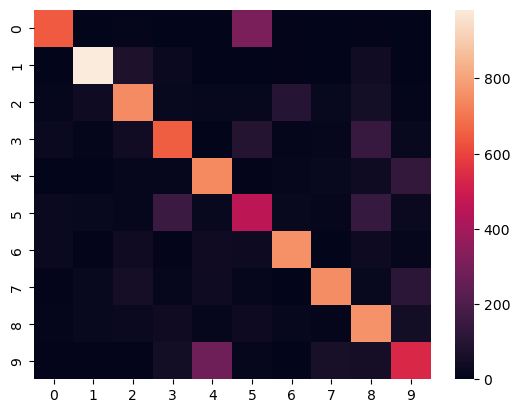

<Figure size 640x480 with 0 Axes>

In [4]:
(trainX, trainY), (testX, testY) = mnist.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2])
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2])
testX = testX.astype('float')/255.0

# build the classifier
model = AdaBoostClassifier(n_estimators = 100)

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

Let's make the individual classifiers a little more sophisticated.


Training Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       1.00      1.00      1.00      6742
           2       1.00      1.00      1.00      5958
           3       1.00      1.00      1.00      6131
           4       1.00      1.00      1.00      5842
           5       1.00      1.00      1.00      5421
           6       1.00      1.00      1.00      5918
           7       1.00      1.00      1.00      6265
           8       1.00      1.00      1.00      5851
           9       1.00      1.00      1.00      5949

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000


Testing Classification Report:

               precision    recall  f1-score   support

           0       0.91      0.93      0.92       980
           1       0.95      0.96      0.96      1135
         

<Figure size 640x480 with 0 Axes>

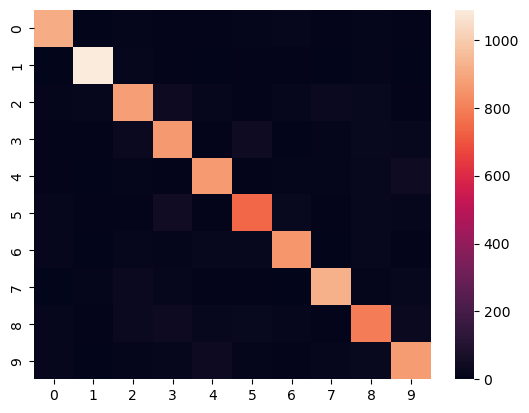

<Figure size 640x480 with 0 Axes>

In [5]:
(trainX, trainY), (testX, testY) = mnist.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2])
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2])
testX = testX.astype('float')/255.0

# build the classifier
model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=None))

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()

/home/rwhite/.local/share/mamba/envs/xai-s26/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
/home/rwhite/.local/share/mamba/envs/xai-s26/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Training Classification Report:

               precision    recall  f1-score   support

           0       0.32      0.39      0.35      5000
           1       0.32      0.32      0.32      5000
           2       0.17      0.34      0.23      5000
           3       0.17      0.15      0.16      5000
           4       0.16      0.10      0.13      5000
           5       0.26      0.20      0.22      5000
           6       0.28      0.19      0.23      5000
           7       0.27      0.21      0.24      5000
           8       0.32      0.35      0.34      5000
           9       0.36      0.32      0.34      5000

    accuracy                           0.26     50000
   macro avg       0.26      0.26      0.25     50000
weighted avg       0.26      0.26      0.25     50000


Testing Classification Report:

               precision    recall  f1-score   support

           0       0.31      0.39      0.35      1000
           1       0.34      0.32      0.33      1000
         

<Figure size 640x480 with 0 Axes>

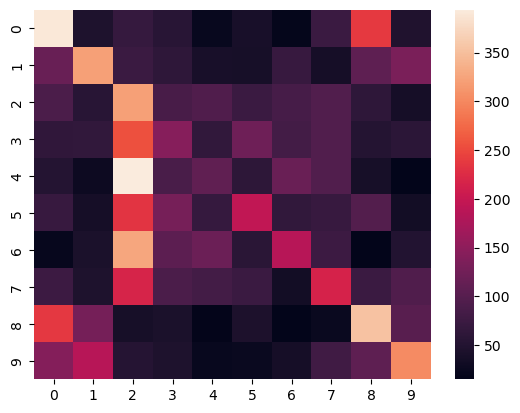

<Figure size 640x480 with 0 Axes>

In [6]:
(trainX, trainY), (testX, testY) = cifar10.load_data()

# preprocess the data
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1] * trainX.shape[2] * 3)
trainX = trainX.astype('float')/255.0

testX = testX.reshape(testX.shape[0], testX.shape[1] * testX.shape[2] * 3)
testX = testX.astype('float')/255.0

# build the classifier
model = AdaBoostClassifier()

# fit the classifier to the training data
model.fit(trainX, trainY)

# predict the labels of the training set
predictedY = model.predict(trainX)

# print quality metrics
print('\nTraining Classification Report:\n\n', classification_report(trainY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

# print quality metrics
print('\nTesting Classification Report:\n\n', classification_report(testY, predictedY))

# predict the labels of the test set
predictedY = model.predict(testX)

print('\nTesting Confusion Matrix:\n')

sn.heatmap(confusion_matrix(testY, predictedY))
plt.figure()